<a href="https://colab.research.google.com/github/ankur-357/MLnew/blob/main/SPORFLibras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!sudo apt-get install build-essential cmake python3-dev libomp-dev libeigen3-dev

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
build-essential is already the newest version (12.9ubuntu3).
cmake is already the newest version (3.22.1-1ubuntu1.22.04.1).
python3-dev is already the newest version (3.10.6-1~22.04).
python3-dev set to manually installed.
The following additional packages will be installed:
  libomp-14-dev libomp5-14
Suggested packages:
  libeigen3-doc libmpfrc++-dev libomp-14-doc
The following NEW packages will be installed:
  libeigen3-dev libomp-14-dev libomp-dev libomp5-14
0 upgraded, 4 newly installed, 0 to remove and 24 not upgraded.
Need to get 1,794 kB of archives.
After this operation, 18.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 libomp5-14 amd64 1:14.0.0-1ubuntu1.1 [389 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 libomp-14-dev amd64 1:14.0.0-1ubuntu1.1 [347 kB]
Get:3 http://archive.ubuntu.com/ubuntu 

In [ ]:
!sudo apt install pip

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
Note, selecting 'python3-pip' instead of 'pip'
The following additional packages will be installed:
  python3-setuptools python3-wheel
Suggested packages:
  python-setuptools-doc
The following NEW packages will be installed:
  python3-pip python3-setuptools python3-wheel
0 upgraded, 3 newly installed, 0 to remove and 24 not upgraded.
Need to get 1,677 kB of archives.
After this operation, 8,967 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 python3-setuptools all 59.6.0-1.2ubuntu0.22.04.1 [339 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 python3-wheel all 0.37.1-2ubuntu0.22.04.1 [32.0 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 python3-pip all 22.0.2+dfsg-1ubuntu0.4 [1,305 kB]
Fetched 1,677 kB in 0s (4,500 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable 

In [ ]:
!pip install -e "git+https://github.com/neurodata/RerF.git@staging#egg=rerf&subdirectory=Python"

Obtaining rerf from git+https://github.com/neurodata/RerF.git@staging#egg=rerf&subdirectory=Python
  Cloning https://github.com/neurodata/RerF.git (to revision staging) to ./src/rerf
  Running command git clone --filter=blob:none --quiet https://github.com/neurodata/RerF.git /content/src/rerf
  Resolved https://github.com/neurodata/RerF.git to commit a7a3c7e6df457b722de86d7254f8a7724b27978f
  Running command git submodule update --init --recursive -q
  Preparing metadata (setup.py) ... done
  Using cached pybind11-2.11.1-py3-none-any.whl (227 kB)
  Running setup.py develop for rerf


In [ ]:
!pip install pyfp


In [ ]:
!pip install rerf

In [ ]:
!pip install pyforest

  Preparing metadata (setup.py) ... done
  Created wheel for pyforest: filename=pyforest-1.1.0-py2.py3-none-any.whl size=14606 sha256=5c48321dfeac569eb1fef15fda411594a4a10b7d67ad450df9ecf361689fb7d8
  Stored in directory: /root/.cache/pip/wheels/9e/7d/2c/5d2f5e62de376c386fd3bf5a8e5bd119ace6a9f48f49df6017
Successfully built pyforest


In [ ]:
!git clone https://github.com/neurodata/RerF.git

Cloning into 'RerF'...
remote: Enumerating objects: 9099, done.
remote: Counting objects: 100% (125/125), done.
remote: Compressing objects: 100% (92/92), done.
remote: Total 9099 (delta 46), reused 93 (delta 32), pack-reused 8974
Receiving objects: 100% (9099/9099), 111.07 MiB | 20.38 MiB/s, done.
Resolving deltas: 100% (5103/5103), done.
Updating files: 100% (2125/2125), done.


In [ ]:
cd RerF/Python

/content/RerF/Python


In [ ]:

!python setup.py clean --all

/usr/local/lib/python3.10/dist-packages/setuptools/__init__.py:84: _DeprecatedInstaller: setuptools.installer and fetch_build_eggs are deprecated.
!!

        ********************************************************************************
        Requirements should be satisfied by a PEP 517 installer.
        If you are using pip, you can try `pip install --use-pep517`.
        ********************************************************************************

!!
  dist.fetch_build_eggs(dist.setup_requires)
running clean
'build/lib.linux-x86_64-cpython-310' does not exist -- can't clean it
'build/bdist.linux-x86_64' does not exist -- can't clean it
'build/scripts-3.10' does not exist -- can't clean it


In [ ]:
!pip install -e .

Obtaining file:///content/RerF/Python
  Preparing metadata (setup.py) ... done
  Attempting uninstall: rerf
    Found existing installation: rerf 2.0.5
    Uninstalling rerf-2.0.5:
      Successfully uninstalled rerf-2.0.5
  Running setup.py develop for rerf


In [ ]:
"""
Example usage of RerF module.

Paths to dataset are relative from "Python" source directory.
"""

from multiprocessing import cpu_count

import numpy as np

from rerf.RerF import fastPredict, fastPredictPost, fastRerF

datatype = "iris"
# datatype = "mnist"

if datatype == "iris":
    datafile = "../packedForest/res/iris.csv"
    label_col = 4
elif datatype == "mnist":
    datafile = "../packedForest/res/mnist.csv"
    label_col = 0

print("loading data...")
X = np.genfromtxt(datafile, delimiter=",")
print("data loaded")

if datatype == "iris":
    feat_data = X[:, 0:4]  # iris
elif datatype == "mnist":
    feat_data = X[:, 1:]  # mnist

labels = X[:, label_col]

# forest = fastRerF(
#     CSVFile=datafile,
#     Ycolumn=label_col,
#     forestType="binnedBaseRerF",
#     trees=500,
#     numCores=cpu_count(),
# )
forest = fastRerF(
    X=feat_data, Y=labels, forestType="binnedBaseRerF", trees=500, numCores=cpu_count()
)

forest.printParameters()

# training predictions
predictions = fastPredict(feat_data, forest)
# print(predictions)

# training posterior predictions probabilities
post_pred = fastPredictPost(feat_data, forest)
# print(post_pred)

print("Error rate", np.mean(predictions != labels))

print("loading test data...")

if datatype == "iris":
    data_fname = "../packedForest/res/iris.csv"  # iris
elif datatype == "mnist":
    data_fname = "../packedForest/res/mnist_test.csv"  # mnist
test_X = np.genfromtxt(data_fname, delimiter=",")

print("data loaded")

if datatype == "iris":
    test_data = test_X[:, 0:4]  # iris
elif datatype == "mnist":
    test_data = test_X[:, 1:]  # mnist

test_pred = fastPredict(test_data, forest)

print("Error rate", np.mean(test_pred != test_X[:, label_col]))


loading data...
data loaded
numTreesInForest -> 500
maxDepth -> 2147483647
minParent -> 1
numClasses -> 3
numObservations -> 150
numFeatures -> 4
mtry -> 2
mtryMult -> 1.5
fractionOfFeaturesToTest -> -1
CSV file name -> 
columnWithY -> -1
Type of Forest -> binnedBaseRerF
binSize -> 0
binMin -> 0
numCores -> 2
seed -> 304778
numTreeBins -> 2
Error rate 0.0
loading test data...
data loaded
Error rate 0.0


In [ ]:
"""
Example shows usage of rerfClassifier class.

Based on https://www.datacamp.com/community/tutorials/random-forests-classifier-python
with rerfClassifier swapped out instead of sklearn's RandomForestClassifier
"""

from rerf.rerfClassifier import rerfClassifier

# Import scikit-learn dataset library
from sklearn import datasets

# Load dataset
iris = datasets.load_iris()


# print the label species(setosa, versicolor,virginica)
print(iris.target_names)

# print the names of the four features
print(iris.feature_names)

# Creating a DataFrame of given iris dataset.
import pandas as pd

data = pd.DataFrame(
    {
        "sepal length": iris.data[:, 0],
        "sepal width": iris.data[:, 1],
        "petal length": iris.data[:, 2],
        "petal width": iris.data[:, 3],
        "species": iris.target,
    }
)
print(data.head())

# Import train_test_split function
from sklearn.model_selection import train_test_split

X = data[["sepal length", "sepal width", "petal length", "petal width"]]  # Features
y = data["species"]  # Labels

# Split dataset into training set and test set
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3
)  # 70% training and 30% test


# Create a Gaussian Classifier
clf = rerfClassifier(n_estimators=100)

print(clf)

# Train the model using the training sets y_pred=clf.predict(X_test)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

# Import scikit-learn metrics module for accuracy calculation
from sklearn import metrics

# Model Accuracy, how often is the classifier correct?
print("Accuracy:", metrics.accuracy_score(y_test, y_pred))


['setosa' 'versicolor' 'virginica']
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
   sepal length  sepal width  petal length  petal width  species
0           5.1          3.5           1.4          0.2        0
1           4.9          3.0           1.4          0.2        0
2           4.7          3.2           1.3          0.2        0
3           4.6          3.1           1.5          0.2        0
4           5.0          3.6           1.4          0.2        0
rerfClassifier(n_estimators=100)
Accuracy: 0.9777777777777777


0.7566565827115422


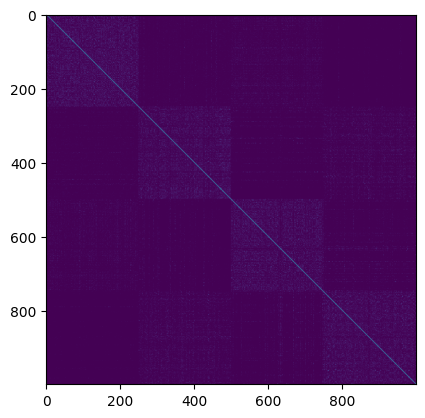

In [ ]:
from matplotlib import pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from sklearn.datasets import make_classification
from sklearn.metrics import adjusted_rand_score
from rerf.urerf import UnsupervisedRandomForest
X, y = make_classification(
   n_samples=1000,
   n_features=4,
   n_informative=2,
   n_redundant=0,
   random_state=0,
   shuffle=False,
)
clf = UnsupervisedRandomForest(n_estimators=100, random_state=0)
clf.fit(X)
sim_mat = clf.transform()
plt.imshow(sim_mat)
cluster = AgglomerativeClustering(n_clusters=2)
predict_labels = cluster.fit_predict(sim_mat)
score = adjusted_rand_score(y, predict_labels)
print(score)

In [ ]:
from rerf.rerfClassifier import rerfClassifier
from sklearn.datasets import make_classification
X, y = make_classification(
   n_samples=1000,
   n_features=4,
   n_informative=2,
   n_redundant=0,
   random_state=0,
   shuffle=False,
)
clf = rerfClassifier(n_estimators=100, max_depth=3, random_state=0)
clf.fit(X, y)

rerfClassifier(feature_combinations=1.5, max_depth=2, max_features='auto',
            min_samples_split=1, n_estimators=100, n_jobs=None,
            projection_matrix='RerF', random_state=0)
print(clf.predict([[0, 0, 0, 0]]))
print(clf.predict_proba([[0, 0, 0, 0]]))

[1]
[[0.26 0.74]]


In [ ]:
import numpy as mp
import pandas as pd

# Specify the correct file path and header argument
data = pd.read_csv("/content/libras.csv", header=None)


In [ ]:
data.head()

,0,1,2,3,4,5,6,7,8,9,...,81,82,83,84,85,86,87,88,89,90
0,0.79691,0.38194,0.79691,0.37731,0.79884,0.37731,0.79497,0.37731,0.77563,0.35417,...,0.51389,0.39845,0.42593,0.47389,0.36111,0.55899,0.31250,0.63830,0.29398,1
1,0.67892,0.27315,0.68085,0.27315,0.68085,0.27315,0.68085,0.27315,0.67892,0.26852,...,0.57407,0.17795,0.63657,0.17215,0.67361,0.17021,0.69213,0.17215,0.69213,1
2,0.72147,0.23611,0.72340,0.23611,0.72340,0.23611,0.72340,0.23611,0.72340,0.23611,...,0.30556,0.59768,0.25926,0.67118,0.25231,0.73501,0.26620,0.78143,0.27778,1
3,0.56480,0.32407,0.56286,0.32407,0.56093,0.32407,0.55899,0.32407,0.55899,0.32407,...,0.49074,0.26306,0.42361,0.33269,0.34722,0.41006,0.28009,0.49130,0.24306,1
4,0.67118,0.38426,0.67118,0.38657,0.67311,0.38657,0.67311,0.38426,0.67311,0.37963,...,0.76389,0.44101,0.64120,0.45068,0.54167,0.47776,0.44213,0.53191,0.34259,1


In [ ]:
data.shape

(360, 91)

In [ ]:
data.columns

Int64Index([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
            17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
            34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
            51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
            68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84,
            85, 86, 87, 88, 89, 90],
           dtype='int64')

In [ ]:
data.isnull().sum()

0     0
1     0
2     0
3     0
4     0
     ..
86    0
87    0
88    0
89    0
90    0
Length: 91, dtype: int64

In [ ]:
# Using data.iloc[:,:-1].values we get the feature variables
X=data.iloc[:,:-1].values

# Using data.iloc[:,-1].values we get the target variable
y=data.iloc[:,-1].values


In [ ]:
# from sklearn.preprocessing import LabelEncoder for performing Label Encoding
from sklearn.preprocessing import LabelEncoder

lbl_class=LabelEncoder()
y_encoded=lbl_class.fit_transform(y)
classes = lbl_class.classes_

In [ ]:
data.sample(50)

,0,1,2,3,4,5,6,7,8,9,...,81,82,83,84,85,86,87,88,89,90
23,0.61896,0.70370,0.61896,0.70370,0.61896,0.70602,0.61702,0.70602,0.61315,0.69444,...,0.694440,0.191490,0.652780,0.237910,0.583330,0.286270,0.509260,0.338490,0.469910,1
289,0.66538,0.71065,0.66151,0.70833,0.66538,0.71065,0.65957,0.71296,0.64603,0.71759,...,0.247690,0.518380,0.250000,0.555130,0.254630,0.589940,0.252310,0.628630,0.247690,13
99,0.53385,0.40741,0.53385,0.40972,0.53578,0.40741,0.53385,0.40972,0.53385,0.40741,...,0.381940,0.970990,0.384260,0.978720,0.402780,0.988390,0.412040,1.000000,0.421300,5
94,0.44874,0.46065,0.44874,0.45833,0.44874,0.45602,0.44874,0.45833,0.44874,0.45370,...,0.759260,0.408120,0.756940,0.433270,0.752310,0.456480,0.750000,0.477760,0.745370,4
162,0.50677,0.64583,0.50677,0.64120,0.50484,0.64815,0.50677,0.64583,0.50677,0.64352,...,0.590280,0.114120,0.590280,0.104450,0.592590,0.094778,0.590280,0.090909,0.585650,7
149,0.88588,0.42824,0.88395,0.42593,0.88395,0.42593,0.88588,0.42824,0.88395,0.42824,...,0.393520,0.717600,0.391200,0.700190,0.391200,0.682790,0.388890,0.665380,0.391200,7
174,0.58414,0.78241,0.58414,0.78241,0.58414,0.78241,0.58414,0.78241,0.58607,0.78241,...,0.157410,0.595740,0.148150,0.591880,0.148150,0.591880,0.152780,0.591880,0.150460,8
196,0.71954,0.39583,0.71954,0.39583,0.71954,0.39352,0.71954,0.39583,0.71954,0.39352,...,0.363430,0.735010,0.372690,0.744680,0.370370,0.744680,0.365740,0.731140,0.349540,9
77,0.62089,0.23148,0.62089,0.23148,0.62282,0.22917,0.62476,0.22917,0.62476,0.22917,...,0.738430,0.611220,0.747690,0.642170,0.756940,0.671180,0.756940,0.702130,0.754630,4
245,0.68859,0.71296,0.69246,0.71065,0.69052,0.71528,0.68859,0.71528,0.69052,0.71296,...,0.238430,0.582210,0.224540,0.531910,0.212960,0.499030,0.210650,0.479690,0.217590,11


In [ ]:
X.shape

(360, 90)

In [ ]:
y.shape

(360,)

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.25)

In [ ]:
from rerf.rerfClassifier import rerfClassifier
clf = rerfClassifier(n_estimators=200, max_features=8, n_jobs = 2, random_state = 40)

In [ ]:
print(y_train)

[ 7  2 12 12 11 11  2  1  1 11  9 11  6  1  7  5 13  8  5  7  2  0 12 10
  9  4  5  3 11  4  9  2 13  4  1 10  4  3  8 12  5  8 14  6  6 12 13  3
  2 11  2  3 14 10 14  6 11 13  4  9 10  1 10 14  1  2  1  3  4  0 13 14
 13  5  3  3  3 14 13  0  5  7  4 14  3 14  3  4  0 12  3  0  0  5  7  9
 12 10  2  7  7  3 12 13  7 12  8  5 11 11  2  9 13  7  8  3  8 10 14 10
  7  5 14  9 12  7 11  5  0  5  4 14 11  2  2  7  9  6  8  4  3  0  8  1
  5 14  6  8  6 13  9 13  8 10  1 10 11  4 13 13  4  9  3  6  1 10 11  7
 11  0  2  2  0  4 13  1  3  5  6  9 11  0 10 14  7  2  0 14 14 13 10  6
  5 13  7  5 12 10  6 13  8 14 11  8  6 13  7  5  1  0  2  9  6  3  5  3
  4  4  1 12  9  3  3  0 11  7 10  2  2  4 10  4 14  8  8  5  1  7  9 13
  8  6 11  8 10  4  9  1  2  4  4  9 11 12  5  5  4  5  2  7 13 10  8 14
 11  6  8  6 12 12]


In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, precision_score, recall_score, f1_score
# Train the model using the training sets y_pred=clf.predict(X_test)
from time import time
# Measure training time
start_time = time()

clf.fit(X_train, y_train)
training_time = time() - start_time
print("Training time:", training_time)

# Measure testing time
start_time = time()

y_pred = clf.predict(X_test)

testing_time = time() - start_time
print("Testing time:", testing_time)

# Import scikit-learn metrics module for accuracy calculation
from sklearn import metrics

y_pred_poba = clf.predict_proba(X_test)
# Model Accuracy, how often is the classifier correct?
print("Accuracy:", metrics.accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average="weighted"))
print("Recall:", recall_score(y_test, y_pred, average="weighted"))
print("F1-Score:", f1_score(y_test, y_pred, average="weighted"))
# Generate and print confusion matrix
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print(y_test.shape)
print(y_pred_poba.shape)
print("ROC AUC Score:", roc_auc_score(y_test, y_pred_poba, multi_class="ovr"))  # Assuming multi-class classification

Training time: 0.43834638595581055
Testing time: 0.013570785522460938
Accuracy: 0.8888888888888888
Precision: 0.895925925925926
Recall: 0.8888888888888888
F1-Score: 0.8890169670561829
Confusion Matrix:
 [[9 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 9 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 5 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 3 0 1 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 3 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 3 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 8 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 4 0 0 1 0 0 0 0]
 [0 0 0 0 0 0 0 0 6 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 7 0 1 0 0 0]
 [0 0 0 0 0 0 0 1 0 0 3 0 2 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 4 0 0 0]
 [0 0 0 0 0 0 0 1 0 0 2 0 6 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 4 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 6]]
(90,)
(90, 15)
ROC AUC Score: 0.9927715147123549


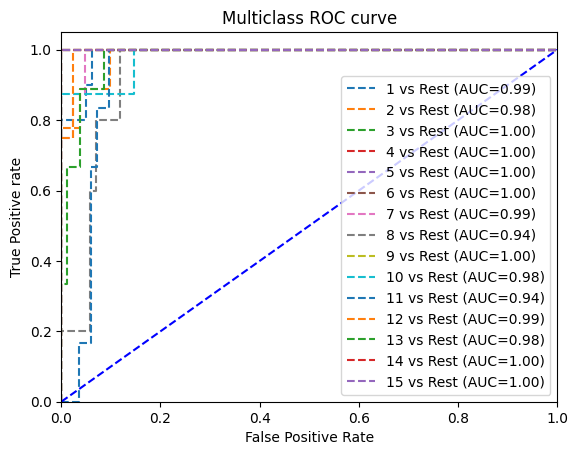

In [ ]:

from sklearn.preprocessing import MinMaxScaler
min_max_scaler=MinMaxScaler()
X_train_norm=min_max_scaler.fit_transform(X_train)
X_test_norm=min_max_scaler.fit_transform(X_test)

from sklearn.multiclass import OneVsRestClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve,auc

#Random Forest Classifier
#because we are dealing with multiclass data and so, the one versus rest strategy is used.
#learn to predict each class against the other.

RF=OneVsRestClassifier(rerfClassifier(n_estimators=300, max_features=8, n_jobs = 2, random_state = 50))
RF.fit(X_train_norm,y_train)
y_pred =RF.predict(X_test_norm)
pred_prob = RF.predict_proba(X_test_norm)

from sklearn.preprocessing import label_binarize
#binarize the y_values

y_test_binarized=label_binarize(y_test,classes=np.unique(y_test))

# roc curve for classes
fpr = {}
tpr = {}
thresh ={}
roc_auc = dict()

n_class = classes.shape[0]

for i in range(n_class):
    fpr[i], tpr[i], thresh[i] = roc_curve(y_test_binarized[:,i], pred_prob[:,i])
    roc_auc[i] = auc(fpr[i], tpr[i])

    # plotting
    plt.plot(fpr[i], tpr[i], linestyle='--',
             label='%s vs Rest (AUC=%0.2f)'%(classes[i],roc_auc[i]))

plt.plot([0,1],[0,1],'b--')
plt.xlim([0,1])
plt.ylim([0,1.05])
plt.title('Multiclass ROC curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive rate')
plt.legend(loc='lower right')
plt.show()


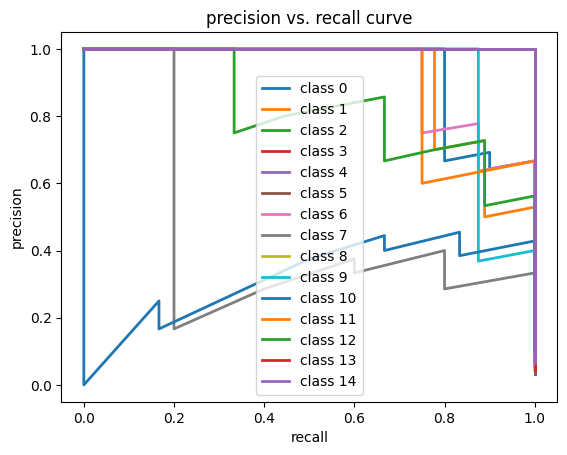

In [ ]:
# precision recall curve
from sklearn.metrics import precision_recall_curve
precision = dict()
recall = dict()
for i in range(n_class):
    precision[i], recall[i], _ = precision_recall_curve(y_test_binarized[:,i], pred_prob[:,i])
    plt.plot(recall[i], precision[i], lw=2, label='class {}'.format(i))

plt.xlabel("recall")
plt.ylabel("precision")
plt.legend(loc="best")
plt.title("precision vs. recall curve")
plt.show()